<a href="https://colab.research.google.com/github/koechjared/git-journey/blob/main/ColabTesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

# --- Step 1: Data Acquisition and Preparation ---

# For demonstration, let's generate a synthetic dataset that mimics loan data.
# In a real-world scenario, you would load your actual debt collection data here.

# Example: Synthetically generated data for loan repayment prediction
# X: Features like credit score, income, loan amount, etc.
# y: Target variable (0 = Default, 1 = Repaid)

X, y = make_classification(
    n_samples=2000,          # Number of debtors
    n_features=15,           # Number of features (e.g., credit score, income, loan amount)
    n_informative=10,        # Number of informative features
    n_redundant=2,           # Number of redundant features
    n_classes=2,             # Binary classification (repaid/defaulted)
    weights=[0.7, 0.3],      # Simulate class imbalance (e.g., 70% repaid, 30% defaulted)
    random_state=42
)

# Convert to DataFrame for easier inspection
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['repayment_status'] = y # Our target variable

print("Generated Synthetic Debt Collection Dataset (first 5 rows):")
display(df.head())
print("\nDataset Information:")
display(df.info())

Generated Synthetic Debt Collection Dataset (first 5 rows):


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,repayment_status
0,-1.017186,2.729893,-3.930462,0.219676,0.237348,0.271265,0.359318,0.863983,0.268122,0.279238,1.337178,1.122232,0.092379,0.078435,0.228464,0
1,-3.514504,3.580012,0.144657,2.010192,-0.949213,0.656822,-0.482043,0.244467,-2.956709,0.783779,0.113646,2.482436,1.555727,0.225325,-1.645638,0
2,2.675246,3.078493,-0.751365,-3.526048,0.265006,4.331090,-0.702386,0.400427,-1.216007,-1.558230,1.268419,-0.569373,0.999083,0.241323,1.884254,1
3,0.602709,-1.348787,0.596659,3.005845,-0.440810,0.882537,2.418747,-1.906175,1.120178,-0.610155,1.836703,1.751925,-1.546711,-1.222733,-2.676214,1
4,0.528297,1.885433,1.902248,-0.894075,0.706407,-3.329306,-0.103802,-4.092994,-2.031218,-0.185011,0.368914,-2.015980,1.404786,-0.246574,0.154608,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   feature_0         2000 non-null   float64
 1   feature_1         2000 non-null   float64
 2   feature_2         2000 non-null   float64
 3   feature_3         2000 non-null   float64
 4   feature_4         2000 non-null   float64
 5   feature_5         2000 non-null   float64
 6   feature_6         2000 non-null   float64
 7   feature_7         2000 non-null   float64
 8   feature_8         2000 non-null   float64
 9   feature_9         2000 non-null   float64
 10  feature_10        2000 non-null   float64
 11  feature_11        2000 non-null   float64
 12  feature_12        2000 non-null   float64
 13  feature_13        2000 non-null   float64
 14  feature_14        2000 non-null   float64
 15  repayment_status  2000 non-null   int64  
dtypes: float64(15), int6

None

In [11]:
print(report)

              precision    recall  f1-score   support

           0       0.94      0.84      0.89       279
           1       0.70      0.88      0.78       121

    accuracy                           0.85       400
   macro avg       0.82      0.86      0.83       400
weighted avg       0.87      0.85      0.85       400



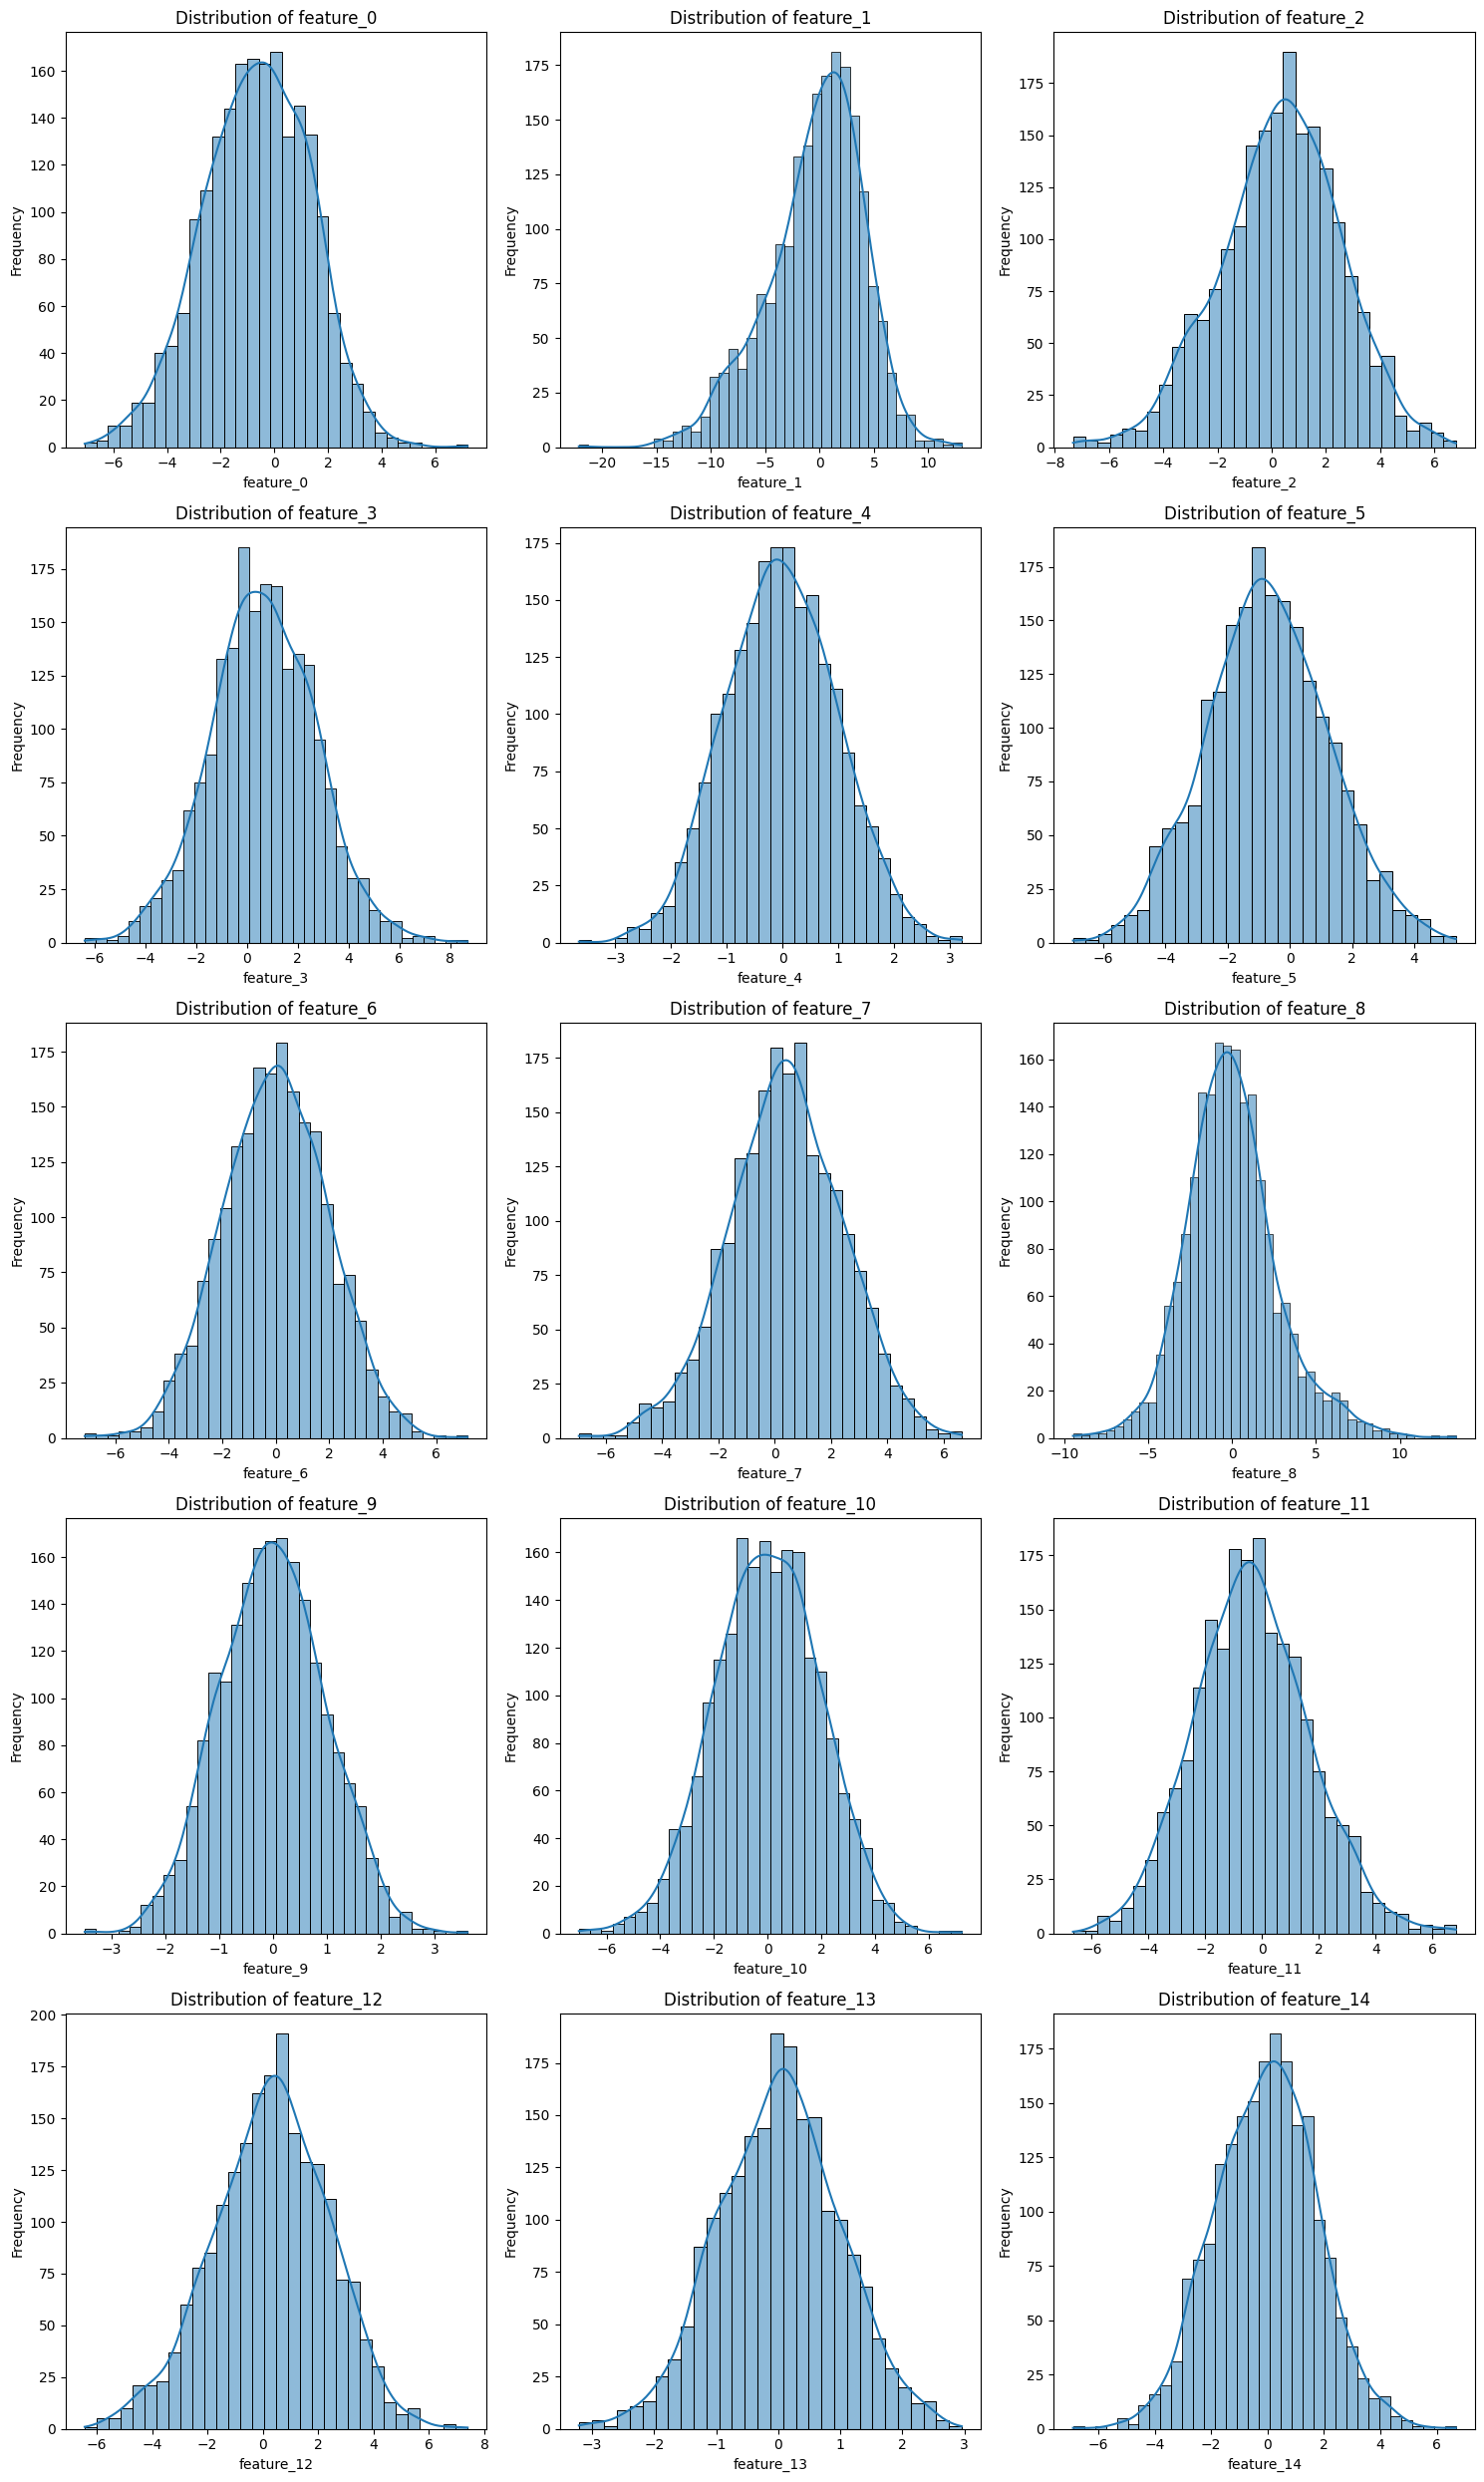

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the DataFrame
# We exclude the 'repayment_status' as it's the target, not a feature we want to visualize distribution for in this manner.
feature_columns = df.drop(columns=['repayment_status']).columns

# Determine the number of rows and columns for the subplot grid
num_features = len(feature_columns)
num_cols = 3 # You can adjust this to your preference
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot histogram for each feature
for i, col in enumerate(feature_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

--- **Action Required: Replace Synthetic Data with Your Real Data** ---

For actual model development, you would replace the synthetic data generation above with code to load your specific debt collection dataset. Here's an example of how you might load data from a CSV:

```python
# import pandas as pd
# # Load your dataset from a CSV file
# try:
#     df = pd.read_csv('your_debt_collection_data.csv')
#     print("Successfully loaded 'your_debt_collection_data.csv'")
# except FileNotFoundError:
#     print("Error: 'your_debt_collection_data.csv' not found. Please ensure the file is in the correct directory.")
#     # Fallback to synthetic data if actual data isn't loaded, or raise an error
#     # For now, we proceed with synthetic data if real data isn't loaded.
#
# # Display information about your actual data
# if 'df' in locals(): # Check if df was loaded
#     display(df.head())
#     display(df.info())
```

Once your data is loaded, the next step is to clearly define your features (`X`) and the target variable (`y`) based on your dataset's column names. For our synthetic example, `X` is already defined by the features and `y` is `repayment_status`.

In [7]:
# Identify Features (X) and Target (y)
# If using your own data, replace 'feature_0', ..., 'feature_14' and 'repayment_status'
# with your actual feature and target column names.

X = df[feature_names] # All feature columns
y = df['repayment_status'] # The target variable

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (2000, 15)
Shape of target (y): (2000,)


With our features (`X`) and target (`y`) defined, the next crucial step is to split the data into training and testing sets. This ensures that we can evaluate our model on unseen data to get a realistic estimate of its performance.

In [8]:
# --- Step 2: Split Data into Training and Testing Sets ---

# We'll split the data into 80% for training and 20% for testing.
# `stratify=y` is important for classification tasks, especially with imbalanced classes,
# to ensure both training and testing sets have a similar proportion of the target classes.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set (X_train, y_train) size: {X_train.shape[0]} samples")
print(f"Testing set (X_test, y_test) size: {X_test.shape[0]} samples")
print(f"\nProportion of '1' (Repaid) in training set: {y_train.mean():.2f}")
print(f"Proportion of '1' (Repaid) in testing set: {y_test.mean():.2f}")

Training set (X_train, y_train) size: 1600 samples
Testing set (X_test, y_test) size: 400 samples

Proportion of '1' (Repaid) in training set: 0.30
Proportion of '1' (Repaid) in testing set: 0.30


Now that our data is split, we can proceed to **Model Selection and Training**. Given this is a binary classification problem for predicting loan repayment likelihood, Logistic Regression is an excellent starting point due to its interpretability and solid baseline performance.

In [9]:
# --- Step 3: Model Selection and Training (Logistic Regression) ---

# Initialize the Logistic Regression model.
# `solver='liblinear'` is good for small datasets and L1/L2 regularization.
# `class_weight='balanced'` is often helpful for imbalanced datasets to give more weight to the minority class.
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model training complete.")

Logistic Regression model training complete.


With the model trained, the next critical step is **Model Evaluation**. We'll make predictions on the unseen test set and assess the model's performance using metrics relevant for classification, especially considering the potential class imbalance in debt collection data.

In [10]:
# --- Step 4: Model Evaluation ---

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy on Test Set: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

# We can also look at the probability scores, which are useful for setting custom thresholds
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (repaid)
print("\nFirst 10 predicted probabilities for repayment:")
print(y_pred_proba[:10])

Model Accuracy on Test Set: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       279
           1       0.70      0.88      0.78       121

    accuracy                           0.85       400
   macro avg       0.82      0.86      0.83       400
weighted avg       0.87      0.85      0.85       400


First 10 predicted probabilities for repayment:
[0.00727899 0.70465617 0.20707367 0.28107766 0.99656281 0.03457146
 0.59267368 0.71109278 0.76644807 0.13287979]


### Interpreting the Results for Debt Collection

*   **Accuracy**: While a general measure, it can be misleading with imbalanced datasets. Our synthetic data had a 70/30 split, so a model predicting all '0' (default) would get 70% accuracy, but be useless.
*   **Precision (for class 1 - Repaid)**: Out of all the debtors the model *predicted* would repay, how many actually did? High precision for '1' means fewer false positives (we don't waste resources on people who won't repay).
*   **Recall (for class 1 - Repaid)**: Out of all the debtors who *actually* repaid, how many did the model correctly identify? High recall for '1' means we identify most potential repayers.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure.
*   **Support**: The number of actual occurrences of each class in the test set.

For debt collection, you'd likely prioritize **Precision for the 'repaid' class (1)** if you want to efficiently allocate resources to high-likelihood repayers, minimizing wasted effort. Conversely, if missing *any* potential repayment is very costly, you might prioritize **Recall for the 'repaid' class (1)**.

Now we have a baseline model. Next steps would involve more advanced feature engineering, trying other models, hyperparameter tuning, and exploring techniques for imbalanced datasets more deeply (e.g., SMOTE, different loss functions).